# 📖 Story Generation using Narrative AI

**Model:** TinyLlama-1.1B fine-tuned with LoRA on Reddit WritingPrompts dataset

**Steps:**
1. Install dependencies
2. Upload & prepare dataset
3. Fine-tune with LoRA
4. Generate stories!

> ⚠️ **Make sure GPU is enabled:** Runtime → Change runtime type → T4 GPU

## Step 1: Install Dependencies

In [1]:
!pip install -q transformers==4.40.2 datasets==2.19.2 peft==0.10.0 accelerate==0.29.3
!pip install -q bitsandbytes scipy sentencepiece

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    props = torch.cuda.get_device_properties(0)
    vram = getattr(props, 'total_memory', getattr(props, 'total_mem', 0))
    print(f"VRAM: {vram / 1e9:.1f} GB")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 68.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.1/542.1 kB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.1/199.1 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.6/297.6 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 88.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
s3fs 2026

## Step 2: Upload & Prepare Dataset

Upload your `writingPrompts (1).tar.gz` file when prompted.

In [2]:
import os

# --- Kaggle: Dataset is already available ---
!tar -xzf /kaggle/input/writingprompts/writingPrompts\ \(1\).tar.gz
print("\u2705 Dataset extracted!")
!ls -la writingPrompts/


tar (child): /kaggle/input/writingprompts/writingPrompts (1).tar.gz: Cannot open: No such file or directory
tar (child): Error is not recoverable: exiting now
tar: Child returned status 2
tar: Error is not recoverable: exiting now
✅ Dataset extracted!
ls: cannot access 'writingPrompts/': No such file or directory


In [3]:
!find / -name "train.wp_source" 2>/dev/null


/kaggle/input/datasets/basavant/writingprompts/writingPrompts/train.wp_source


In [4]:
import json
import re
import random
import os
import glob

def clean_prompt(text):
    text = re.sub(r'\[\s*\w+\s*\]', '', text)
    return text.strip()

def clean_story(text):
    text = text.replace('<newline>', '\n')
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()

# ---- CONFIG ----
MAX_SAMPLES = 5000       # Number of training examples
MAX_STORY_CHARS  = 3500   # Max story length in characters
# ----------------

# --- Auto-detect dataset path ---
possible_paths = [
    "writingPrompts",                                               # after tar extraction
    "/kaggle/input/writingprompts/writingPrompts",                  # direct Kaggle dataset
    "/kaggle/input/writingprompts",                                 # flat Kaggle dataset
]

DATA_DIR = None
for p in possible_paths:
    if os.path.exists(os.path.join(p, "train.wp_source")):
        DATA_DIR = p
        break

# Fallback: search for the file
if DATA_DIR is None:
    found = glob.glob("/kaggle/input/**/train.wp_source", recursive=True)
    if found:
        DATA_DIR = os.path.dirname(found[0])

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find train.wp_source! "
        "Make sure the writingPrompts dataset is attached as input."
    )

print(f"Found dataset at: {DATA_DIR}")
print("Reading dataset...")

with open(os.path.join(DATA_DIR, 'train.wp_source'), 'r', encoding='utf-8') as f:
    prompts = f.readlines()
with open(os.path.join(DATA_DIR, 'train.wp_target'), 'r', encoding='utf-8') as f:
    stories = f.readlines()

print(f"Total examples in dataset: {len(prompts)}")

examples = []
skipped = 0
for prompt, story in zip(prompts, stories):
    prompt = clean_prompt(prompt)
    story = clean_story(story)
    if len(prompt) < 10 or len(story) < 50:
        skipped += 1
        continue
    if len(story) > MAX_STORY_CHARS:
        cut = story[:MAX_STORY_CHARS].rfind('.')
        story = story[:cut + 1] if cut > MAX_STORY_CHARS // 2 else story[:MAX_STORY_CHARS]
    examples.append({
        'input': f"Write a creative story based on this prompt: {prompt}",
        'output': story
    })

random.seed(42)
random.shuffle(examples)
examples = examples[:MAX_SAMPLES]

with open('story_data.jsonl', 'w', encoding='utf-8') as f:
    for ex in examples:
        f.write(json.dumps(ex, ensure_ascii=False) + '\n')

print(f"Prepared {len(examples)} examples (skipped {skipped} short ones)")
print(f"\nSample prompt: {examples[0]['input'][:150]}...")
print(f"Sample story:  {examples[0]['output'][:200]}...")


Found dataset at: /kaggle/input/datasets/basavant/writingprompts/writingPrompts
Reading dataset...
Total examples in dataset: 272600
Prepared 5000 examples (skipped 1584 short ones)

Sample prompt: Write a creative story based on this prompt: For the first time since the Fall , God and Satan sit at the same discussion table to figure out how to d...
Sample story:  Threefeets sensors had made contact , a target was acquired and he looked up protocol # CA330B67F1 . The protocol was pretty clear on what he had to do . If the scan showed a human , Threefeet had to ...


## Step 3: Fine-Tune TinyLlama with LoRA

This trains only ~2M parameters (instead of 1.1B) using LoRA adapters.
Takes about **1-2 hours** on a T4 GPU with 5000 samples.

In [5]:
import json
import copy
import torch
from torch.nn.utils.rnn import pad_sequence
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    BitsAndBytesConfig,
    EarlyStoppingCallback,
)
from datasets import Dataset
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, TaskType

# ============================================================
# TRAINING CONFIG  (5K samples | 500 steps | T4 x2 safe)
# ============================================================
MODEL_NAME      = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
OUTPUT_DIR      = "./story_model_output"
MAX_SAMPLES     = 5000           # dataset cap
MAX_STEPS = 2500            # training steps
BATCH_SIZE      = 4              # per-GPU batch
GRAD_ACCUM      = 4              # effective batch = 16
LEARNING_RATE = 5e-5           # lower LR for stable convergence
LORA_R = 64             # higher rank for richer story learning
LORA_ALPHA = 128             # alpha = 2 * rank
MAX_SOURCE_LEN  = 256            # max prompt tokens
MAX_TARGET_LEN = 1024            # longer stories (was 512)
USE_4BIT        = True           # QLoRA - saves VRAM on T4
WARMUP_STEPS    = 50             # smooth learning rate warmup
SAVE_STEPS      = 100            # checkpoint every 100 steps
LOG_STEPS       = 10             # log every 10 steps
# ============================================================
# Estimated training time on Kaggle T4 x2:
#   ~2-3 sec/step x 500 steps = ~20 - 30 mins  (well within 12h limit)
# ============================================================

IGNORE_INDEX = -100

print("Loading data...")
examples = []
with open('story_data.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        examples.append(json.loads(line.strip()))

# Cap to MAX_SAMPLES
if len(examples) > MAX_SAMPLES:
    import random
    random.seed(42)
    random.shuffle(examples)
    examples = examples[:MAX_SAMPLES]

eval_size     = max(1, len(examples) // 20)   # 5% eval split
eval_examples  = examples[:eval_size]
train_examples = examples[eval_size:]

train_dataset = Dataset.from_list(train_examples)
eval_dataset  = Dataset.from_list(eval_examples)
print(f"Train: {len(train_dataset):,} samples  |  Eval: {len(eval_dataset):,} samples")
print(f"Steps: {MAX_STEPS}  |  Effective batch: {BATCH_SIZE * GRAD_ACCUM}  |  LR: {LEARNING_RATE}")


2026-05-06 17:41:00.751887: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778089261.021694      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778089261.096319      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778089261.712080      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778089261.712114      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778089261.712118      23 computation_placer.cc:177] computation placer alr

Loading data...
Train: 4,750 samples  |  Eval: 250 samples
Steps: 2500  |  Effective batch: 16  |  LR: 5e-05


In [6]:
# --- Load Model with 4-bit Quantization ---
print(f"Loading model: {MODEL_NAME}...")

quantization_config = None
if USE_4BIT and torch.cuda.is_available():
    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )
    print("Using 4-bit quantization (QLoRA)")

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    quantization_config=quantization_config,
    trust_remote_code=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.add_special_tokens({'pad_token': '[PAD]'})
    model.resize_token_embeddings(len(tokenizer))

print(f"\u2705 Model loaded!")

Loading model: TinyLlama/TinyLlama-1.1B-Chat-v1.0...
Using 4-bit quantization (QLoRA)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

✅ Model loaded!


In [7]:
# --- Apply LoRA ---
if USE_4BIT:
    model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                    "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.08,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
model.config.use_cache = False

trainable params: 50,462,720 || all params: 1,150,511,104 || trainable%: 4.386113252149889


In [8]:
# --- Data Collator ---
class StoryDataCollator:
    def __init__(self, tokenizer, max_source_len=256, max_target_len=512):
        self.tokenizer = tokenizer
        self.max_source_len = max_source_len
        self.max_target_len = max_target_len

    def __call__(self, instances):
        sources = [f"{self.tokenizer.bos_token}### Human: {ex['input']}\n### Assistant: " for ex in instances]
        targets = [f"{ex['output']}{self.tokenizer.eos_token}" for ex in instances]

        tok_src = self.tokenizer(sources, max_length=self.max_source_len, truncation=True, add_special_tokens=False)
        tok_tgt = self.tokenizer(targets, max_length=self.max_target_len, truncation=True, add_special_tokens=False)

        input_ids, labels = [], []
        for s, t in zip(tok_src['input_ids'], tok_tgt['input_ids']):
            input_ids.append(torch.tensor(s + t))
            labels.append(torch.tensor([IGNORE_INDEX] * len(s) + copy.deepcopy(t)))

        input_ids = pad_sequence(input_ids, batch_first=True, padding_value=self.tokenizer.pad_token_id)
        labels = pad_sequence(labels, batch_first=True, padding_value=IGNORE_INDEX)

        return {
            'input_ids': input_ids,
            'attention_mask': input_ids.ne(self.tokenizer.pad_token_id),
            'labels': labels,
        }

data_collator = StoryDataCollator(tokenizer, MAX_SOURCE_LEN, MAX_TARGET_LEN)
print("\u2705 Data collator ready!")

✅ Data collator ready!


In [9]:
# --- Train! ---
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    max_steps=MAX_STEPS,
    learning_rate=LEARNING_RATE,
    lr_scheduler_type="cosine",
    warmup_steps=150,
    label_smoothing_factor=0.1,
    weight_decay=0.01,
    logging_steps=10,
    save_steps=100,
    save_total_limit=3,
    evaluation_strategy="steps",
    eval_steps=100,
    fp16=True,
    remove_unused_columns=False,
    report_to="none",
    seed=42,
    gradient_checkpointing=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
)

print("\n" + "="*60)
print(f"🚀 Starting training: {MAX_STEPS} steps")
print(f"   Effective batch size: {BATCH_SIZE * GRAD_ACCUM}")
print(f"   Learning rate: {LEARNING_RATE}")
print("="*60 + "\n")

trainer.train()

# Save
trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"\n\u2705 Training complete! Model saved to {OUTPUT_DIR}")

/usr/local/lib/python3.12/dist-packages/accelerate/accelerator.py:469: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  self.scaler = torch.cuda.amp.GradScaler(**kwargs)
max_steps is given, it will override any value given in num_train_epochs



🚀 Starting training: 2500 steps
   Effective batch size: 16
   Learning rate: 5e-05



/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:865: UserWarning: The AccumulateGrad node's stream does not match the stream of the node that produced the incoming gradient. This may incur unnecessary synchronization and break CUDA graph capture if the AccumulateGrad node's stream is the default stream. This mismatch is caused by an AccumulateGrad node created prior to the current iteration being kept alive. This can happen if the autograd graph is still being kept alive by tensors such a

Step,Training Loss,Validation Loss
100,3.766300,3.773904
200,3.697900,3.701288
300,3.667600,3.683671
400,3.628300,3.674654
500,3.589900,3.667575
600,3.625000,3.663381
700,3.555500,3.666180
800,3.610900,3.662536
900,3.582400,3.665212
1000,3.539300,3.671296


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a n


✅ Training complete! Model saved to ./story_model_output


## Step 4: Generate Stories! 📝

Now use the fine-tuned model to generate stories from any prompt.

In [10]:
from peft import PeftModel

# --- Load fine-tuned model ---
print("Loading fine-tuned model...")

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    trust_remote_code=True,
)
base_model.resize_token_embeddings(len(tokenizer))

model = PeftModel.from_pretrained(base_model, OUTPUT_DIR)
model = model.merge_and_unload()
model.eval()

print("\u2705 Model ready for story generation!")

Loading fine-tuned model...
✅ Model ready for story generation!


In [11]:
def generate_story(prompt, max_tokens=512, temperature=0.6, top_p=0.90, repetition_penalty=1.2):
    """Generate a story from a prompt."""
    formatted = f"{tokenizer.bos_token}### Human: Write a creative story based on this prompt: {prompt}\n### Assistant: "

    inputs = tokenizer(formatted, return_tensors="pt", add_special_tokens=False)
    input_ids = inputs['input_ids'].to(model.device)
    attention_mask = inputs['attention_mask'].to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_tokens,
            temperature=temperature,
            top_p=top_p,
            top_k=40,
            repetition_penalty=repetition_penalty,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )

    generated = outputs[0][input_ids.shape[1]:]
    story = tokenizer.decode(generated, skip_special_tokens=True)
    return story.strip()

In [12]:
# ============================
# Try These Story Prompts!
# ============================

prompts = [
    # --- Human emotions ---
    "A child writes a letter to the friend they lost years ago",
    "An old man plants a tree he knows he will never see fully grown",

    # --- Identity & self-discovery ---
    "A girl who was always told she was ordinary discovers what makes her different",
    "A soldier returns home after the war and must learn to be himself again",

    # --- Nature & wonder ---
    "A lighthouse keeper discovers that every ship he guides carries a secret",
    "A farmer finds a letter buried beneath the oldest tree on his land",

    # --- Technology & humanity ---
    "A robot programmed to clean streets begins collecting lost things people leave behind",
    "The last human on a space station receives a message from Earth",

    # --- Hope & resilience ---
    "After losing everything in a flood, a family finds a photograph that changes everything",
    "A young doctor in a small village performs a miracle with no medicine at all",
]

for i, prompt in enumerate(prompts, 1):
    print(f"\n{'='*70}")
    print(f"Prompt {i}: {prompt}")
    print('='*70)
    story = generate_story(prompt)
    print(story)
    print()



Prompt 1: A child writes a letter to the friend they lost years ago
Dearest Sophie , 
 
 I know you are reading this . It has been so long since we last spoke that it is hard to believe that you even exist anymore . I hope you have n't forgotten me , or how much I mean to you . You were my best friend and I miss you more than anything in this world . 
 
 Please write back soon and tell me all about your life . I would love to hear what you are doing now . The past few months have been tough for both of us . I just want to go back to our old routine and see you again . Do n't leave me again . 
 
 Love , 
 David 
 
 -- - 
 
 `` Hi David , '' said Sophie as she sat down next to him at his desk . He looked up from his book with a smile . `` How are things ? '' 
 
 `` Oh , yeah . Things are good . '' He chuckled . `` You still remember that letter I wrote to you ? '' he asked her as he pulled out a piece of paper and began to read it aloud . `` I think I 'm going to send that off today . '

## Step 5: Evaluate Generated Stories

Automatically compute quality metrics on the fine-tuned model's output:

| Metric | What it measures | Direction |
|---|---|---|
| **Perplexity** | Fluency of generated text | Lower = better |
| **ROUGE-1/2/L** | N-gram overlap with reference stories | Higher = better |
| **BERTScore F1** | Semantic similarity to reference stories | Higher = better |
| **METEOR** | Synonym-aware text similarity | Higher = better |
| **Distinct-1 / Distinct-2** | Lexical diversity / creativity | Higher = better |
| **Repetition Rate** | Within-story 3-gram repetition | Lower = better |


In [13]:
# Install evaluation dependencies
!pip install -q bert-score rouge-score nltk
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('omw-1.4', quiet=True)
print("Evaluation packages ready!")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 1.8 MB/s eta 0:00:00
Evaluation packages ready!


In [14]:
import math, json, random
from collections import Counter
import torch
from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn
from nltk.translate.meteor_score import meteor_score

# ============================================================
# CONFIG — 50 samples for reliable, low-variance metrics
NUM_EVAL_SAMPLES = 50
# ============================================================

# Load eval samples
all_examples = []
with open("story_data.jsonl", "r", encoding="utf-8") as _f:
    for _line in _f:
        all_examples.append(json.loads(_line.strip()))

random.seed(42)
eval_samples = random.sample(all_examples, min(NUM_EVAL_SAMPLES, len(all_examples)))
print(f"Evaluating on {len(eval_samples)} samples...")

# Generate stories for each eval prompt
generated_stories, reference_stories = [], []
for i, ex in enumerate(eval_samples):
    raw_prompt = ex["input"].replace("Write a creative story based on this prompt: ", "")
    gen = generate_story(raw_prompt, max_tokens=600)
    generated_stories.append(gen)
    reference_stories.append(ex["output"])
    if (i + 1) % 10 == 0:
        print(f"  Generated {i+1}/{len(eval_samples)} stories...")

print("Story generation complete. Running metrics...\n")

Evaluating on 50 samples...
  Generated 10/50 stories...
  Generated 20/50 stories...
  Generated 30/50 stories...
  Generated 40/50 stories...
  Generated 50/50 stories...
Story generation complete. Running metrics...



In [15]:
# ── 1. PERPLEXITY ──────────────────────────────────────────────────────────
def compute_perplexity(texts, mdl, tok, dev):
    mdl.eval()
    total_loss, total_tokens = 0.0, 0
    with torch.no_grad():
        for text in texts:
            enc = tok(text, return_tensors="pt", truncation=True, max_length=512).to(dev)
            out = mdl(**enc, labels=enc["input_ids"])
            n   = enc["input_ids"].size(1)
            total_loss   += out.loss.item() * n
            total_tokens += n
    return math.exp(total_loss / total_tokens)

_device = next(model.parameters()).device
ppl = compute_perplexity(generated_stories, model, tokenizer, _device)
print(f"Perplexity       : {ppl:.2f}  (lower = more fluent)")

Perplexity       : 4.13  (lower = more fluent)


In [16]:
# ── 2. ROUGE ────────────────────────────────────────────────────────────────
_scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

r1_scores, r2_scores, rL_scores = [], [], []
for ref, gen in zip(reference_stories, generated_stories):
    s = _scorer.score(ref, gen)
    r1_scores.append(s["rouge1"].fmeasure)
    r2_scores.append(s["rouge2"].fmeasure)
    rL_scores.append(s["rougeL"].fmeasure)

avg_r1 = sum(r1_scores) / len(r1_scores)
avg_r2 = sum(r2_scores) / len(r2_scores)
avg_rL = sum(rL_scores) / len(rL_scores)
print(f"ROUGE-1 (avg F1) : {avg_r1:.4f}")
print(f"ROUGE-2 (avg F1) : {avg_r2:.4f}")
print(f"ROUGE-L (avg F1) : {avg_rL:.4f}  (higher = better n-gram overlap)")

ROUGE-1 (avg F1) : 0.3237
ROUGE-2 (avg F1) : 0.0409
ROUGE-L (avg F1) : 0.1255  (higher = better n-gram overlap)


In [17]:
# ── 3. BERTScore ────────────────────────────────────────────────────────────
P, R, F1 = bert_score_fn(
    generated_stories, reference_stories,
    lang="en",
    model_type="roberta-large",
    rescale_with_baseline=False,
    verbose=False
)
bs_p  = P.mean().item()
bs_r  = R.mean().item()
bs_f1 = F1.mean().item()
print(f"BERTScore P      : {bs_p:.4f}  (roberta-large, no baseline rescaling)")
print(f"BERTScore R      : {bs_r:.4f}")
print(f"BERTScore F1     : {bs_f1:.4f}  (higher = better semantic similarity)")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERTScore P      : 0.8286  (roberta-large, no baseline rescaling)
BERTScore R      : 0.8182
BERTScore F1     : 0.8233  (higher = better semantic similarity)


In [18]:
# ── 4. DISTINCT-1 / DISTINCT-2 ──────────────────────────────────────────────
def distinct_n(texts, n=1):
    all_ng, unique_ng = [], set()
    for text in texts:
        toks = text.split()
        grams = [tuple(toks[i:i+n]) for i in range(len(toks) - n + 1)]
        all_ng.extend(grams)
        unique_ng.update(grams)
    return len(unique_ng) / max(len(all_ng), 1)

d1 = distinct_n(generated_stories, n=1)
d2 = distinct_n(generated_stories, n=2)
print(f"Distinct-1       : {d1:.4f}  (higher = more diverse vocabulary)")
print(f"Distinct-2       : {d2:.4f}  (higher = more creative bigrams)")

# ── 5. REPETITION RATE ──────────────────────────────────────────────────────
def repetition_rate(texts, n=3):
    rates = []
    for text in texts:
        toks = text.split()
        if len(toks) < n:
            continue
        grams  = [tuple(toks[i:i+n]) for i in range(len(toks) - n + 1)]
        counts = Counter(grams)
        repeated = sum(v - 1 for v in counts.values() if v > 1)
        rates.append(repeated / len(grams))
    return sum(rates) / len(rates) if rates else 0.0

rep = repetition_rate(generated_stories, n=3)
print(f"Repetition Rate  : {rep:.4f}  (lower = less repetitive text)")

# ── 6. METEOR ───────────────────────────────────────────────────────────────
meteor_scores = []
for ref, gen in zip(reference_stories, generated_stories):
    score = meteor_score([ref.split()], gen.split())
    meteor_scores.append(score)
avg_meteor = sum(meteor_scores) / len(meteor_scores)
print(f"METEOR (avg)     : {avg_meteor:.4f}  (higher = better, handles synonyms)")

# ── 7. STORY LENGTH STATS ───────────────────────────────────────────────────
gen_lens = [len(s.split()) for s in generated_stories]
ref_lens = [len(s.split()) for s in reference_stories]
avg_gen_len = sum(gen_lens) / len(gen_lens)
avg_ref_len = sum(ref_lens) / len(ref_lens)
length_ratio = avg_gen_len / max(avg_ref_len, 1)
print(f"Avg generated len: {avg_gen_len:.0f} words")
print(f"Avg reference len: {avg_ref_len:.0f} words")
print(f"Length ratio     : {length_ratio:.2f}x  (1.0 = same length as reference)")

Distinct-1       : 0.1188  (higher = more diverse vocabulary)
Distinct-2       : 0.5228  (higher = more creative bigrams)
Repetition Rate  : 0.0289  (lower = less repetitive text)
METEOR (avg)     : 0.2040  (higher = better, handles synonyms)
Avg generated len: 422 words
Avg reference len: 520 words
Length ratio     : 0.81x  (1.0 = same length as reference)


In [19]:
# ── EVALUATION SUMMARY ──────────────────────────────────────────────────────
metrics_summary = {
    "Perplexity":      (f"{ppl:.2f}",         "lower is better"),
    "ROUGE-1 F1":      (f"{avg_r1:.4f}",      "higher is better"),
    "ROUGE-2 F1":      (f"{avg_r2:.4f}",      "higher is better"),
    "ROUGE-L F1":      (f"{avg_rL:.4f}",      "higher is better"),
    "METEOR":          (f"{avg_meteor:.4f}",  "higher is better"),
    "BERTScore F1":    (f"{bs_f1:.4f}",       "higher is better"),
    "Distinct-1":      (f"{d1:.4f}",          "higher is better"),
    "Distinct-2":      (f"{d2:.4f}",          "higher is better"),
    "Repetition Rate": (f"{rep:.4f}",         "lower is better"),
    "Avg Story Length": (f"{avg_gen_len:.0f} words", "informational"),
    "Length Ratio":    (f"{length_ratio:.2f}x",     "1.0 = same as reference"),
}

print("=" * 62)
print("   NARRATIVE AI STORY GENERATION — EVALUATION SUMMARY")
print("=" * 62)
print(f"   {'Metric':<22} {'Score':>12}   {'Direction'}")
print("-" * 62)
for name, (score, direction) in metrics_summary.items():
    print(f"   {name:<22} {score:>12}   {direction}")
print("=" * 62)
print(f"   Model  : TinyLlama-1.1B + LoRA (r=64)")
print(f"   Samples: {len(eval_samples)} story samples evaluated")
print("=" * 62)

   NARRATIVE AI STORY GENERATION — EVALUATION SUMMARY
   Metric                        Score   Direction
--------------------------------------------------------------
   Perplexity                     4.13   lower is better
   ROUGE-1 F1                   0.3237   higher is better
   ROUGE-2 F1                   0.0409   higher is better
   ROUGE-L F1                   0.1255   higher is better
   METEOR                       0.2040   higher is better
   BERTScore F1                 0.8233   higher is better
   Distinct-1                   0.1188   higher is better
   Distinct-2                   0.5228   higher is better
   Repetition Rate              0.0289   lower is better
   Avg Story Length          422 words   informational
   Length Ratio                  0.81x   1.0 = same as reference
   Model  : TinyLlama-1.1B + LoRA (r=64)
   Samples: 50 story samples evaluated


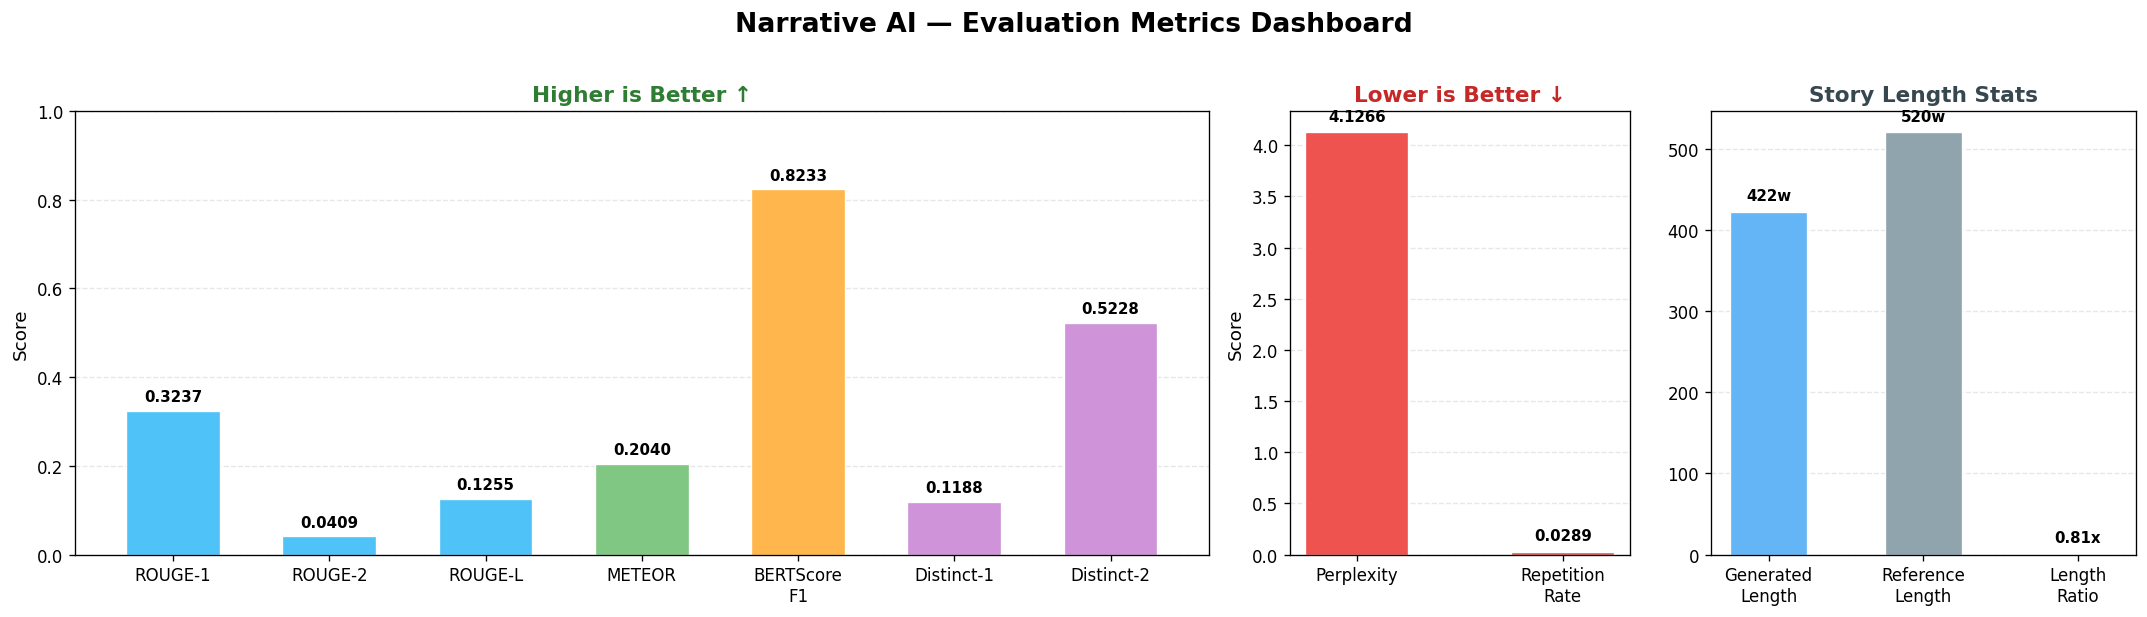


Chart saved as eval_metrics_chart.png


In [20]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.family'] = 'sans-serif'

# ── Define metric groups for visualization ──
# Group 1: "Higher is better" metrics (0–1 scale)
higher_names  = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L', 'METEOR', 'BERTScore\nF1', 'Distinct-1', 'Distinct-2']
higher_scores = [avg_r1,    avg_r2,    avg_rL,    avg_meteor, bs_f1,      d1,          d2]
higher_colors = ['#4FC3F7', '#4FC3F7', '#4FC3F7', '#81C784',  '#FFB74D',  '#CE93D8',   '#CE93D8']

# Group 2: "Lower is better" metrics
lower_names  = ['Perplexity', 'Repetition\nRate']
lower_scores = [ppl,          rep]
lower_colors = ['#EF5350',    '#EF5350']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), gridspec_kw={'width_ratios': [4, 1.2, 1.5]})
fig.suptitle('Narrative AI — Evaluation Metrics Dashboard', fontsize=16, fontweight='bold', y=1.02)

# ── Plot 1: Higher-is-better bar chart ──
ax1 = axes[0]
bars1 = ax1.bar(higher_names, higher_scores, color=higher_colors, edgecolor='white', linewidth=0.8, width=0.6)
ax1.set_ylim(0, 1.0)
ax1.set_ylabel('Score', fontsize=11)
ax1.set_title('Higher is Better ↑', fontsize=13, fontweight='bold', color='#2E7D32')
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.set_axisbelow(True)
for bar, val in zip(bars1, higher_scores):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── Plot 2: Lower-is-better bar chart ──
ax2 = axes[1]
bars2 = ax2.bar(lower_names, lower_scores, color=lower_colors, edgecolor='white', linewidth=0.8, width=0.5)
ax2.set_ylabel('Score', fontsize=11)
ax2.set_title('Lower is Better ↓', fontsize=13, fontweight='bold', color='#C62828')
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.set_axisbelow(True)
for bar, val in zip(bars2, lower_scores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(lower_scores)*0.02,
             f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ── Plot 3: Length comparison ──
ax3 = axes[2]
categories = ['Generated\nLength', 'Reference\nLength', 'Length\nRatio']
values = [avg_gen_len, avg_ref_len, length_ratio]
bar_colors = ['#64B5F6', '#90A4AE', '#FFD54F']
bars3 = ax3.bar(categories, values, color=bar_colors, edgecolor='white', linewidth=0.8, width=0.5)
ax3.set_title('Story Length Stats', fontsize=13, fontweight='bold', color='#37474F')
ax3.grid(axis='y', alpha=0.3, linestyle='--')
ax3.set_axisbelow(True)
for bar, val in zip(bars3, values):
    label = f'{val:.0f}w' if val > 2 else f'{val:.2f}x'
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.02,
             label, ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('eval_metrics_chart.png', bbox_inches='tight', dpi=150, facecolor='white')
plt.show()
print("\nChart saved as eval_metrics_chart.png")